# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as ss

pd.set_option("display.max_columns", 8, "display.max_rows", 10, "display.max_colwidth", 12)

## Introduction

## Summary Statistics

### How to do it...

In [2]:
fueleco = pd.read_csv("../data/vehicles.csv.zip")
fueleco

/tmp/ipykernel_76106/2459232533.py:1: DtypeWarning: Columns (70,71,72,73,74,76,79) have mixed types. Specify dtype option on import or set low_memory=False.
  fueleco = pd.read_csv("../data/vehicles.csv.zip")


,barrels08,barrelsA08,charge120,charge240,...,startStop,phevCity,phevHwy,phevComb
0,15.695714,0.0,0.0,0.0,...,NaN,0,0,0
1,29.964545,0.0,0.0,0.0,...,NaN,0,0,0
2,12.207778,0.0,0.0,0.0,...,NaN,0,0,0
3,29.964545,0.0,0.0,0.0,...,NaN,0,0,0
4,17.347895,0.0,0.0,0.0,...,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...
39096,14.982273,0.0,0.0,0.0,...,NaN,0,0,0
39097,14.330870,0.0,0.0,0.0,...,NaN,0,0,0
39098,15.695714,0.0,0.0,0.0,...,NaN,0,0,0
39099,15.695714,0.0,0.0,0.0,...,NaN,0,0,0


/tmp/ipykernel_5166/2459232533.py:1: DtypeWarning: Columns (70,71,72,73,74,76,79) have mixed types. Specify dtype option on import or set low_memory=False.
  fueleco = pd.read_csv("../data/vehicles.csv.zip")

In [3]:
print(fueleco.iloc[:,[70,71,72,73,74,76,79]].info())
pd.concat([
    fueleco.iloc[:,[70,71,72,73,74,76,79]].describe().T,
    fueleco.iloc[:,[70,71,72,73,74,76,79]].dtypes,
    ],
    axis="columns").rename(columns={0: "dtype"})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   fuelType2  1490 non-null   object
 1   rangeA     1485 non-null   object
 2   evMotor    644 non-null    object
 3   mfrCode    8289 non-null   object
 4   c240Dscr   53 non-null     object
 5   c240bDscr  51 non-null     object
 6   startStop  7405 non-null   object
dtypes: object(7)
memory usage: 2.1+ MB
None


,count,unique,top,freq,dtype
fuelType2,1490,4,E85,1383,object
rangeA,1485,216,290,74,object
evMotor,644,125,288V Ni-MH,117,object
mfrCode,8289,46,GMX,1255,object
c240Dscr,53,5,standard...,42,object
c240bDscr,51,4,80 amp d...,42,object
startStop,7405,2,N,5176,object


In [4]:
try:
    fueleco.mean()  # doctest: +SKIP
except TypeError as e:
    print("TypeError: ", e)
    display(fueleco.select_dtypes(np.number).mean().to_frame().rename(columns={0: "mean"}))

TypeError:  can only concatenate str (not "int") to str


,mean
barrels08,17.442712
barrelsA08,0.219276
charge120,0.000000
charge240,0.029630
city08,18.077799
...,...
youSaveSpend,-3459.572645
charge240b,0.005869
phevCity,0.094703
phevHwy,0.094269


In [5]:
try:
    fueleco.std()  # doctest: +SKIP
except TypeError as e:
    print("TypeError: ", e)
    display(fueleco.select_dtypes(np.number).std().to_frame().rename(columns={0: "std"}))

TypeError:  could not convert string to float: 'Rear-Wheel Drive'


,std
barrels08,4.580230
barrelsA08,1.143837
charge120,0.000000
charge240,0.487408
city08,6.970672
...,...
youSaveSpend,3010.284617
charge240b,0.165399
phevCity,2.279478
phevHwy,2.191115


In [6]:
try:
    fueleco.quantile([0, 0.25, 0.5, 0.75, 1])  # doctest: +SKIP
except TypeError as e:
    print("TypeError: ", e)
    display(fueleco.select_dtypes(np.number).quantile([0, 0.25, 0.5, 0.75, 1]).T)

TypeError:  numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.


,0.00,0.25,0.50,0.75,1.00
barrels08,0.06,14.33087,17.347895,20.115,47.087143
barrelsA08,0.00,0.00000,0.000000,0.000,18.311667
charge120,0.00,0.00000,0.000000,0.000,0.000000
charge240,0.00,0.00000,0.000000,0.000,12.000000
city08,6.00,15.00000,17.000000,20.000,150.000000
...,...,...,...,...,...
youSaveSpend,-26500.00,-4750.00000,-3500.000000,-1500.000,5250.000000
charge240b,0.00,0.00000,0.000000,0.000,7.000000
phevCity,0.00,0.00000,0.000000,0.000,97.000000
phevHwy,0.00,0.00000,0.000000,0.000,81.000000


In [7]:
fueleco.describe()  # doctest: +SKIP

,barrels08,barrelsA08,charge120,charge240,...,charge240b,phevCity,phevHwy,phevComb
count,39101.00...,39101.00...,39101.0,39101.00...,...,39101.00...,39101.00...,39101.00...,39101.00...
mean,17.442712,0.219276,0.0,0.029630,...,0.005869,0.094703,0.094269,0.094141
std,4.580230,1.143837,0.0,0.487408,...,0.165399,2.279478,2.191115,2.226500
min,0.060000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000
25%,14.330870,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000
50%,17.347895,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000
75%,20.115000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000
max,47.087143,18.311667,0.0,12.000000,...,7.000000,97.000000,81.000000,88.000000


In [8]:
fueleco.describe(include=object)  # doctest: +SKIP

,drive,eng_dscr,fuelType,fuelType1,...,c240bDscr,createdOn,modifiedOn,startStop
count,37912,23431,39101,39101,...,51,39101,39101,7405
unique,7,545,14,6,...,4,195,68,2
top,Front-Wh...,(FFS),Regular,Regular ...,...,80 amp d...,Tue Jan ...,Tue Jan ...,N
freq,13653,8827,25620,26931,...,42,34199,29438,5176


### How it works...

### There's more...

In [9]:
fueleco.describe().T  # doctest: +SKIP

,count,mean,std,min,25%,50%,75%,max
barrels08,39101.0,17.442712,4.580230,0.06,14.33087,17.347895,20.115,47.087143
barrelsA08,39101.0,0.219276,1.143837,0.00,0.00000,0.000000,0.000,18.311667
charge120,39101.0,0.000000,0.000000,0.00,0.00000,0.000000,0.000,0.000000
charge240,39101.0,0.029630,0.487408,0.00,0.00000,0.000000,0.000,12.000000
city08,39101.0,18.077799,6.970672,6.00,15.00000,17.000000,20.000,150.000000
...,...,...,...,...,...,...,...,...
youSaveSpend,39101.0,-3459.572645,3010.284617,-26500.00,-4750.00000,-3500.000000,-1500.000,5250.000000
charge240b,39101.0,0.005869,0.165399,0.00,0.00000,0.000000,0.000,7.000000
phevCity,39101.0,0.094703,2.279478,0.00,0.00000,0.000000,0.000,97.000000
phevHwy,39101.0,0.094269,2.191115,0.00,0.00000,0.000000,0.000,81.000000


## Column Types

### How to do it...

In [10]:
fueleco.dtypes

barrels08     float64
barrelsA08    float64
charge120     float64
charge240     float64
city08          int64
               ...   
modifiedOn     object
startStop      object
phevCity        int64
phevHwy         int64
phevComb        int64
Length: 83, dtype: object

In [11]:
fueleco.dtypes.value_counts()

float64    32
int64      27
object     23
bool        1
Name: count, dtype: int64

### How it works...

### There's more...

In [12]:
fueleco.select_dtypes("int64").describe().T

,count,mean,std,min,25%,50%,75%,max
city08,39101.0,18.077799,6.970672,6.0,15.0,17.0,20.0,150.0
cityA08,39101.0,0.569883,4.297124,0.0,0.0,0.0,0.0,145.0
co2,39101.0,72.538989,163.252019,-1.0,-1.0,-1.0,-1.0,847.0
co2A,39101.0,5.543950,55.956932,-1.0,-1.0,-1.0,-1.0,713.0
comb08,39101.0,20.323828,6.882807,7.0,17.0,20.0,23.0,136.0
...,...,...,...,...,...,...,...,...
year,39101.0,2000.635406,10.690422,1984.0,1991.0,2001.0,2010.0,2018.0
youSaveSpend,39101.0,-3459.572645,3010.284617,-26500.0,-4750.0,-3500.0,-1500.0,5250.0
phevCity,39101.0,0.094703,2.279478,0.0,0.0,0.0,0.0,97.0
phevHwy,39101.0,0.094269,2.191115,0.0,0.0,0.0,0.0,81.0


In [13]:
np.iinfo(np.int8)

iinfo(min=-128, max=127, dtype=int8)

In [14]:
np.iinfo(np.int16)

iinfo(min=-32768, max=32767, dtype=int16)

In [15]:
fueleco[["city08", "comb08"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   city08  39101 non-null  int64
 1   comb08  39101 non-null  int64
dtypes: int64(2)
memory usage: 611.1 KB


In [16]:
(
    fueleco[["city08", "comb08"]]
    .assign(
        city08=fueleco.city08.astype(np.int16),
        comb08=fueleco.comb08.astype(np.int16)
    )
    .info()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   city08  39101 non-null  int16
 1   comb08  39101 non-null  int16
dtypes: int16(2)
memory usage: 152.9 KB


In [17]:
fueleco.make.nunique()

134

In [18]:
fueleco.model.nunique()

3816

In [19]:
fueleco[["make"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   make    39101 non-null  object
dtypes: object(1)
memory usage: 305.6+ KB


In [20]:
(
    fueleco[["make"]].assign(
        make=fueleco.make.astype("category"))
        .info()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   make    39101 non-null  category
dtypes: category(1)
memory usage: 81.6 KB


In [21]:
fueleco[["model"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   model   39101 non-null  object
dtypes: object(1)
memory usage: 305.6+ KB


In [22]:
(fueleco[["model"]].assign(model=fueleco.model.astype("category")).info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39101 entries, 0 to 39100
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   model   39101 non-null  category
dtypes: category(1)
memory usage: 235.3 KB


## Categorical Data

### How to do it...

In [23]:
fueleco.select_dtypes(object).columns

Index(['drive', 'eng_dscr', 'fuelType', 'fuelType1', 'make', 'model',
       'mpgData', 'trany', 'VClass', 'guzzler', 'trans_dscr', 'tCharger',
       'sCharger', 'atvType', 'fuelType2', 'rangeA', 'evMotor', 'mfrCode',
       'c240Dscr', 'c240bDscr', 'createdOn', 'modifiedOn', 'startStop'],
      dtype='object')

In [24]:
fueleco.drive.nunique()

7

In [25]:
fueleco.drive.sample(5, random_state=42)

4217     4-Wheel ...
1736     4-Wheel ...
36029    Rear-Whe...
37631    Front-Wh...
1668     Rear-Whe...
Name: drive, dtype: object

In [26]:
fueleco.drive.isna().sum()

1189

In [27]:
fueleco.drive.isna().mean() * 100

3.0408429451932175

In [28]:
fueleco.drive.value_counts()

drive
Front-Wheel Drive             13653
Rear-Wheel Drive              13284
4-Wheel or All-Wheel Drive     6648
All-Wheel Drive                2401
4-Wheel Drive                  1221
2-Wheel Drive                   507
Part-time 4-Wheel Drive         198
Name: count, dtype: int64

In [29]:
fueleco.make.value_counts().size

134

In [30]:
top_n = fueleco.make.value_counts().index[:6]
top_n


Index(['Chevrolet', 'Ford', 'Dodge', 'GMC', 'Toyota', 'BMW'], dtype='object', name='make')

In [31]:
fueleco.make.isin(top_n)

0        False
1        False
2         True
3         True
4        False
         ...  
39096    False
39097    False
39098    False
39099    False
39100    False
Name: make, Length: 39101, dtype: bool

In [32]:
pd.concat(
    [
        fueleco.make,
        fueleco.make.isin(top_n),
        fueleco.make.where(fueleco.make.isin(top_n)), # Keep values where condition is True, others default to NaN but can be reassigned
        fueleco.make.mask(fueleco.make.isin(top_n)),  # Keep values where condition is False, , others default to NaN but can be reassigned
    ], axis="columns"
).set_axis(["make", "boolean_array", "where_function", "mask_function"], axis="columns")

,make,boolean_array,where_function,mask_function
0,Alfa Romeo,False,NaN,Alfa Romeo
1,Ferrari,False,NaN,Ferrari
2,Dodge,True,Dodge,NaN
3,Dodge,True,Dodge,NaN
4,Subaru,False,NaN,Subaru
...,...,...,...,...
39096,Subaru,False,NaN,Subaru
39097,Subaru,False,NaN,Subaru
39098,Subaru,False,NaN,Subaru
39099,Subaru,False,NaN,Subaru


In [33]:
(
    fueleco.assign(
        make=fueleco.make.where(fueleco.make.isin(top_n), "Other")
    ).make.value_counts()
)

make
Other        23211
Chevrolet     3900
Ford          3208
Dodge         2557
GMC           2442
Toyota        1976
BMW           1807
Name: count, dtype: int64

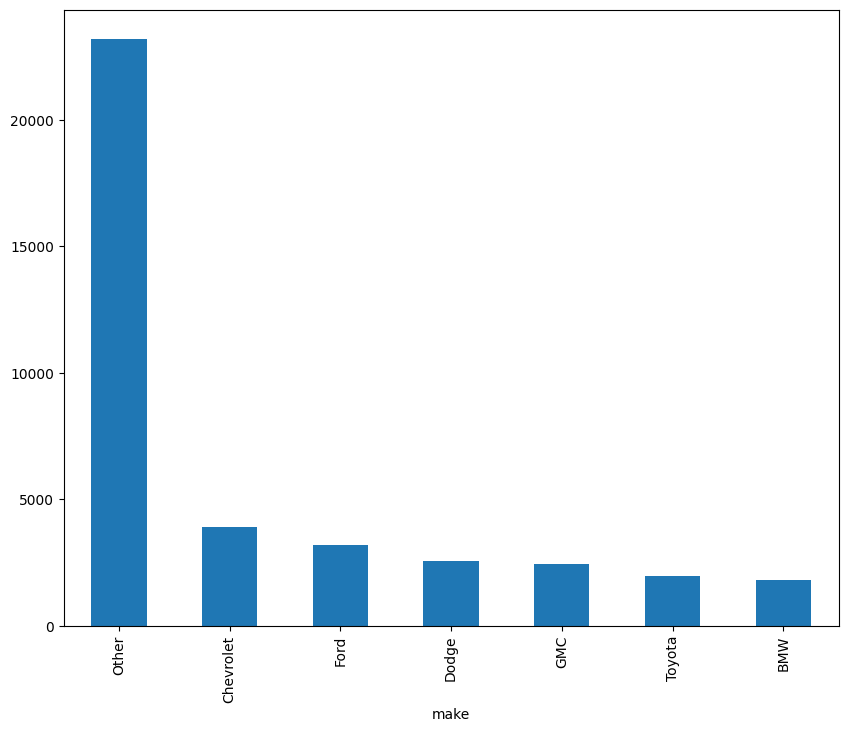

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
top_n = fueleco.make.value_counts().index[:6]
(
    fueleco.assign(  # doctest: +SKIP
        make=fueleco.make.where(fueleco.make.isin(top_n), "Other")
    )
    .make.value_counts()
    .plot.bar(ax=ax)
)
fig.savefig("/tmp/c5-catpan.png", dpi=300)  # doctest: +SKIP

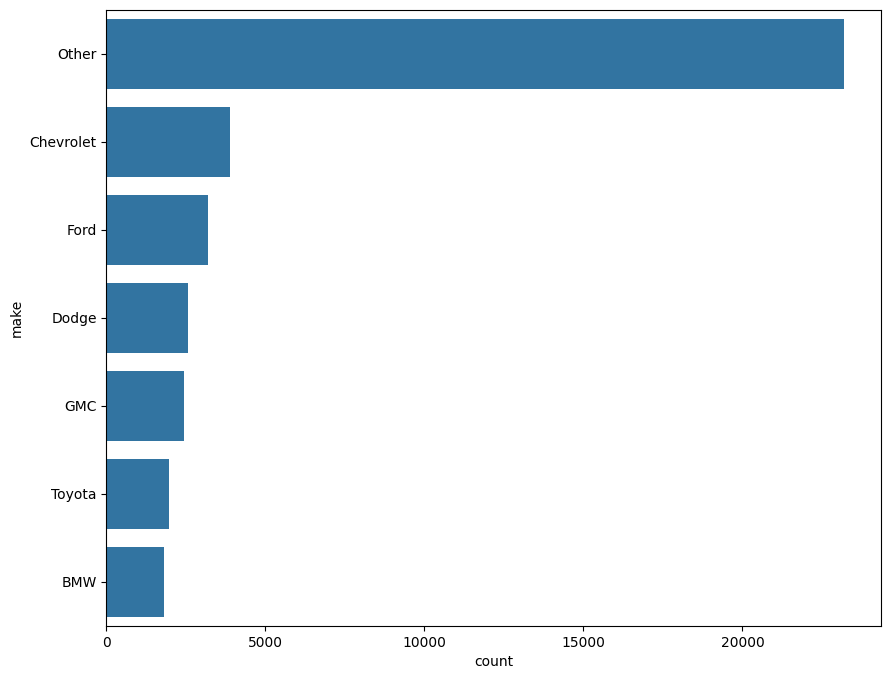

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
top_n = fueleco.make.value_counts().index[:6]
fuelco_make_imputed = fueleco.assign(make=fueleco.make.where(fueleco.make.isin(top_n), "Other"))

sns.countplot(
    y="make",  # doctest: +SKIP
    data=fuelco_make_imputed,
    order=fuelco_make_imputed.make.value_counts().index
)
fig.savefig("/tmp/c5-catsns.png", dpi=300)  # doctest: +SKIP

### How it works...

In [36]:
fueleco[fueleco.drive.isna()]

,barrels08,barrelsA08,charge120,charge240,...,startStop,phevCity,phevHwy,phevComb
7138,0.240000,0.0,0.0,0.0,...,N,0,0,0
8144,0.312000,0.0,0.0,0.0,...,N,0,0,0
8147,0.270000,0.0,0.0,0.0,...,N,0,0,0
18215,15.695714,0.0,0.0,0.0,...,NaN,0,0,0
18216,14.982273,0.0,0.0,0.0,...,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...
23023,0.240000,0.0,0.0,0.0,...,N,0,0,0
23024,0.546000,0.0,0.0,0.0,...,N,0,0,0
23026,0.426000,0.0,0.0,0.0,...,N,0,0,0
23031,0.426000,0.0,0.0,0.0,...,N,0,0,0


### How to do it...

In [37]:
fueleco.drive.isna().sum()

1189

In [38]:
fueleco.drive.value_counts(dropna=False)

drive
Front-Wheel Drive             13653
Rear-Wheel Drive              13284
4-Wheel or All-Wheel Drive     6648
All-Wheel Drive                2401
4-Wheel Drive                  1221
NaN                            1189
2-Wheel Drive                   507
Part-time 4-Wheel Drive         198
Name: count, dtype: int64

In [39]:
(
    fueleco.drive.value_counts(dropna=False)
        .to_frame()
        .reset_index()
        .set_axis(["drive", "count_dropna_False"], axis='columns')
        .merge(fueleco.drive.value_counts()
                    .to_frame()
                    .reset_index()
                    .set_axis(["drive", "count_dropna_True"], axis='columns')
                    .assign(count_dropna_True= lambda _df : _df.count_dropna_True.astype(pd.Int64Dtype())),
                how='left')
)

,drive,count_dropna_False,count_dropna_True
0,Front-Wh...,13653,13653
1,Rear-Whe...,13284,13284
2,4-Wheel ...,6648,6648
3,All-Whee...,2401,2401
4,4-Wheel ...,1221,1221
5,NaN,1189,<NA>
6,2-Wheel ...,507,507
7,Part-tim...,198,198


### There's more...

In [40]:
# note the `/`and `-` in the index => numeric column posing as a categorical one
fueleco.rangeA.value_counts()

rangeA
290            74
270            56
280            53
310            41
277            38
               ..
351             1
240/290/290     1
303             1
340-350         1
341             1
Name: count, Length: 216, dtype: int64

In [41]:
# another way to find offending characters with `str.extract`
(
    fueleco.rangeA.str.extract(r"([^0-9.])") # matches any single character that is neither a digit nor a period.
    .dropna()
    .apply(lambda row: "".join(row), axis="columns") # perhaps intended to turn the DataFrame into a Series
    .value_counts()
)

/    280
-     71
Name: count, dtype: int64

In [42]:
set(fueleco.rangeA.apply(type))

{float, str}

In [43]:
fueleco.rangeA.isna().sum()

37616

In [44]:
(
    fueleco.rangeA.fillna("0")
    .str.replace("-", "/")
    .str.split("/", expand=True) # split numeric values in distinct cols
    .astype(float)
    .mean(axis=1) # take the mean of the distinct cols
)

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
39096    0.0
39097    0.0
39098    0.0
39099    0.0
39100    0.0
Length: 39101, dtype: float64

In [45]:
(
    fueleco.rangeA.fillna("0")
    .str.replace("-", "/")
    .str.split("/", expand=True)
    .astype(float)
    .mean(axis=1)
    .pipe(lambda ser_: pd.cut(ser_, 10)) # bin values in equal-width bins, or width that we specify
    .value_counts()
)

(-0.45, 44.95]     37688
(269.7, 314.65]      559
(314.65, 359.6]      352
(359.6, 404.55]      205
(224.75, 269.7]      181
(404.55, 449.5]       82
(89.9, 134.85]        12
(179.8, 224.75]        9
(44.95, 89.9]          8
(134.85, 179.8]        5
Name: count, dtype: int64

In [46]:
(
    fueleco.rangeA.fillna("0")
    .str.replace("-", "/")
    .str.split("/", expand=True)
    .astype(float)
    .mean(axis=1)
    .pipe(lambda ser_: pd.qcut(ser_, 10)) # bin values in bins with the same size => can't quantile most of the values `0` so it fails here
    .value_counts()
)

ValueError: Bin edges must be unique: Index([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 449.5], dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

dtype('int64')

<Axes: xlabel='city08'>

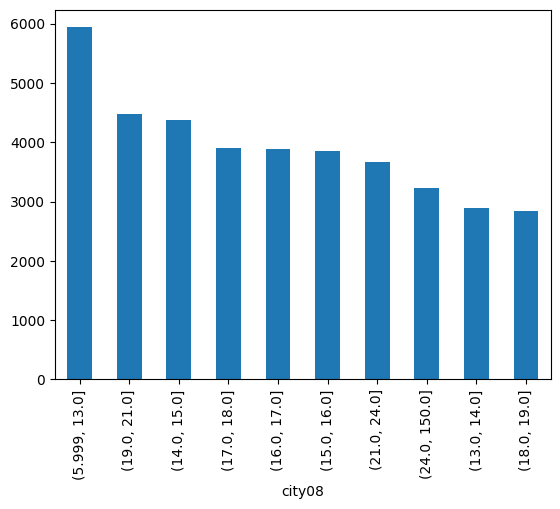

In [47]:
# As city is is an int data type, the bins will have similar sizes, but it won't be perfect
display(fueleco.city08.dtype)
(
    fueleco.city08.pipe(lambda ser: pd.qcut(ser, q=10))
    .value_counts()
).plot(kind='bar')

## Continuous Data

### How to do it...

In [48]:
fueleco.select_dtypes("number")

,barrels08,barrelsA08,charge120,charge240,...,charge240b,phevCity,phevHwy,phevComb
0,15.695714,0.0,0.0,0.0,...,0.0,0,0,0
1,29.964545,0.0,0.0,0.0,...,0.0,0,0,0
2,12.207778,0.0,0.0,0.0,...,0.0,0,0,0
3,29.964545,0.0,0.0,0.0,...,0.0,0,0,0
4,17.347895,0.0,0.0,0.0,...,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
39096,14.982273,0.0,0.0,0.0,...,0.0,0,0,0
39097,14.330870,0.0,0.0,0.0,...,0.0,0,0,0
39098,15.695714,0.0,0.0,0.0,...,0.0,0,0,0
39099,15.695714,0.0,0.0,0.0,...,0.0,0,0,0


In [49]:
fueleco.city08.sample(5, random_state=42)

4217     11
1736     21
36029    16
37631    16
1668     17
Name: city08, dtype: int64

In [50]:
fueleco.city08.isna().sum()

0

In [51]:
fueleco.city08.isna().mean() * 100

0.0

In [52]:
fueleco.city08.describe()

count    39101.00...
mean       18.077799
std         6.970672
min         6.000000
25%        15.000000
50%        17.000000
75%        20.000000
max       150.000000
Name: city08, dtype: float64

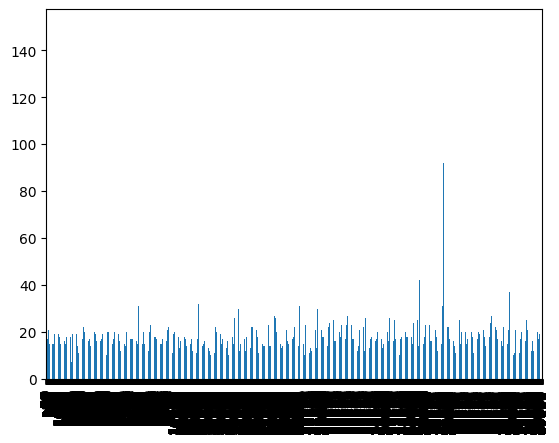

In [53]:
fueleco.city08.plot(kind="bar");

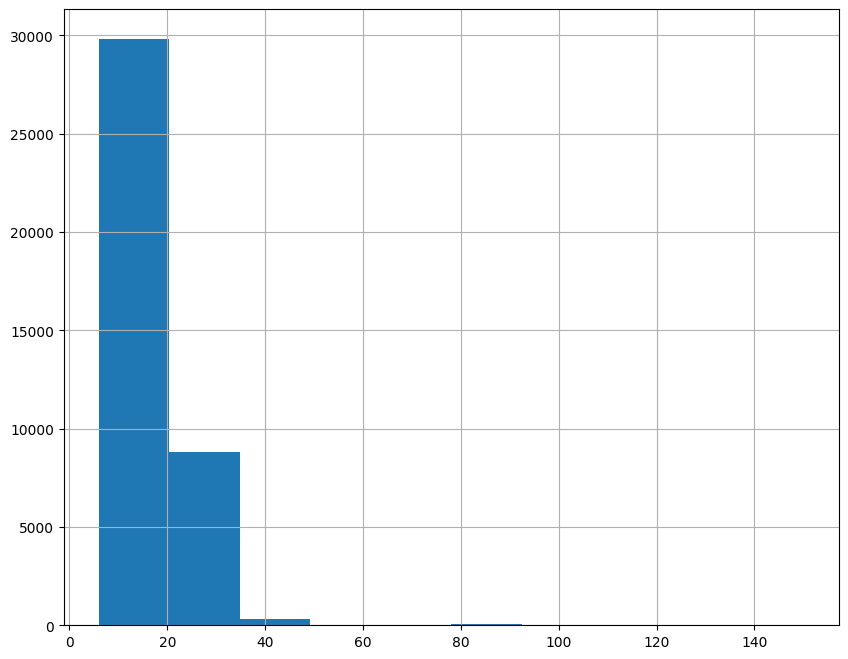

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))
fueleco.city08.hist(ax=ax)
fig.savefig("/tmp/c5-conthistpan.png", dpi=300)  # doctest: +SKIP

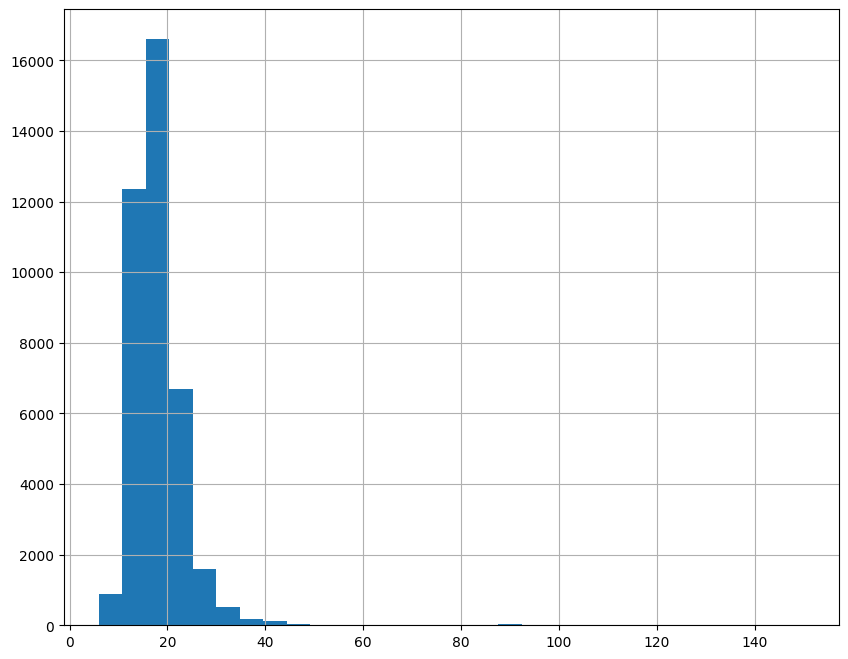

In [55]:
fig, ax = plt.subplots(figsize=(10, 8))
fueleco.city08.hist(ax=ax, bins=30)
fig.savefig("/tmp/c5-conthistpanbins.png", dpi=300)  # doctest: +SKIP

Seaborn functions are broadly divided into two categories: 

- "Axes-level" 
    - such as sns.scatterplot, sns.regplot, sns.kdeplot, and sns.boxplot, 
    - accept an explicit ax argument and are designed to draw directly onto a specified Matplotlib axes
- and "Figure-level" functions.
    - sns.relplot, sns.catplot, sns.displot, sns.pairplot, and sns.jointplot 
    - create their own figure and axes, and they cannot be directly plotted onto an existing ax.

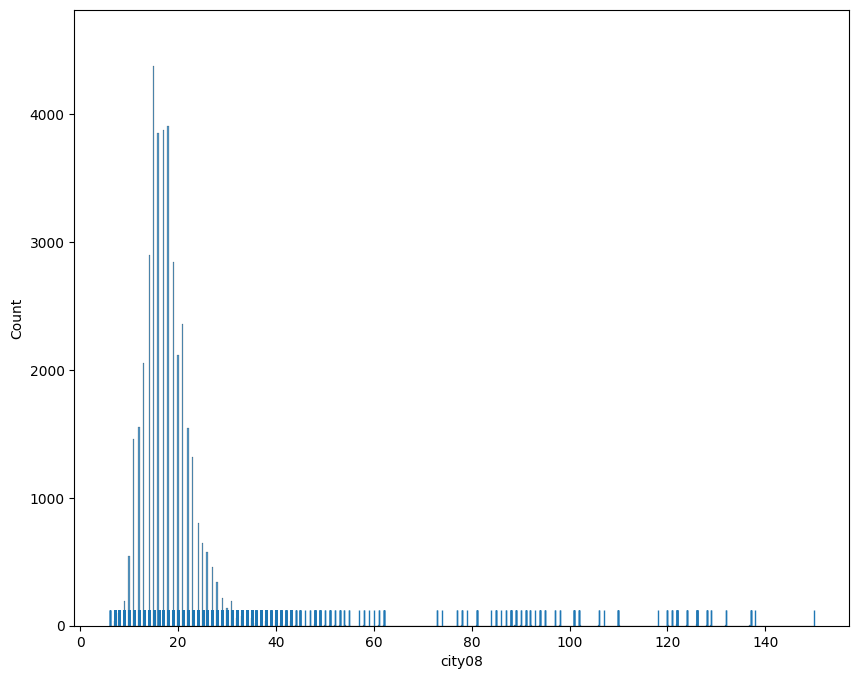

In [56]:
fig, ax = plt.subplots(figsize=(10, 8))
#sns.distplot(fueleco.city08, rug=True, ax=ax) # `distplot` is a deprecated function and will be removed in seaborn v0.14.0.
sns.rugplot(fueleco.city08, ax=ax)
sns.histplot(fueleco.city08, ax=ax)
fig.savefig("/tmp/c5-conthistsns.png", dpi=300);  # doctest: +SKIP

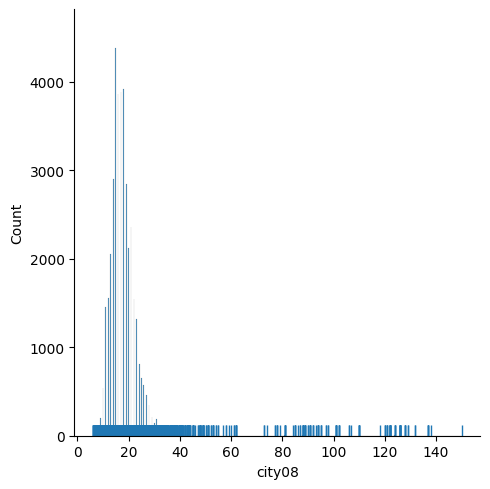

In [57]:
sns.displot(fueleco.city08, rug=True);

### How it works...

### There's more...

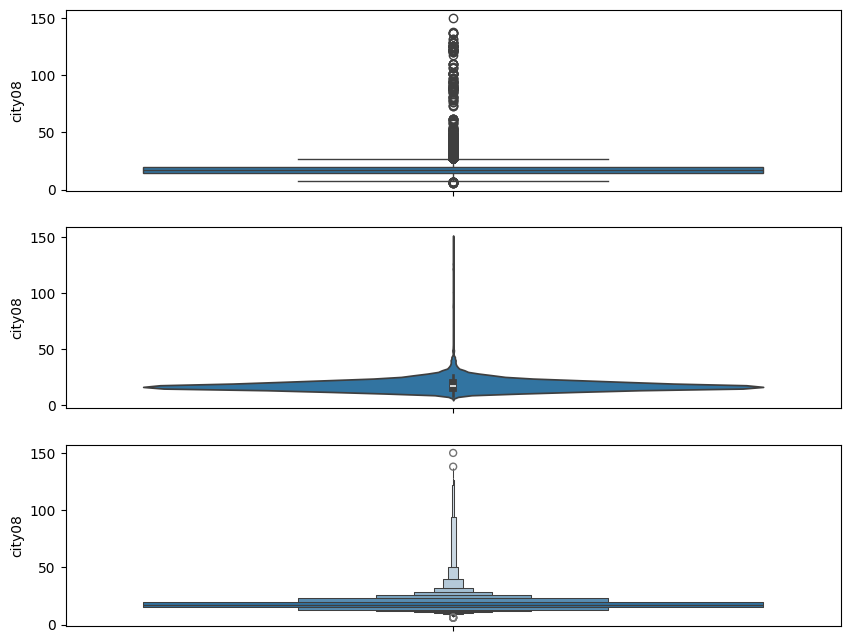

In [58]:
fig, axs = plt.subplots(nrows=3, figsize=(10, 8))
sns.boxplot(fueleco.city08, ax=axs[0])
sns.violinplot(fueleco.city08, ax=axs[1])
sns.boxenplot(fueleco.city08, ax=axs[2])
fig.savefig("/tmp/c5-contothersns.png", dpi=300)

In [ ]:
# p-value to estimate if a distribution is normal
# typically, with p-value over 5%, the "normal distribution hypothesis" can be rejected
stats.kstest(fueleco.city08, cdf="norm")

KstestResult(statistic=0.9999999990134123, pvalue=0.0, statistic_location=6, statistic_sign=-1)

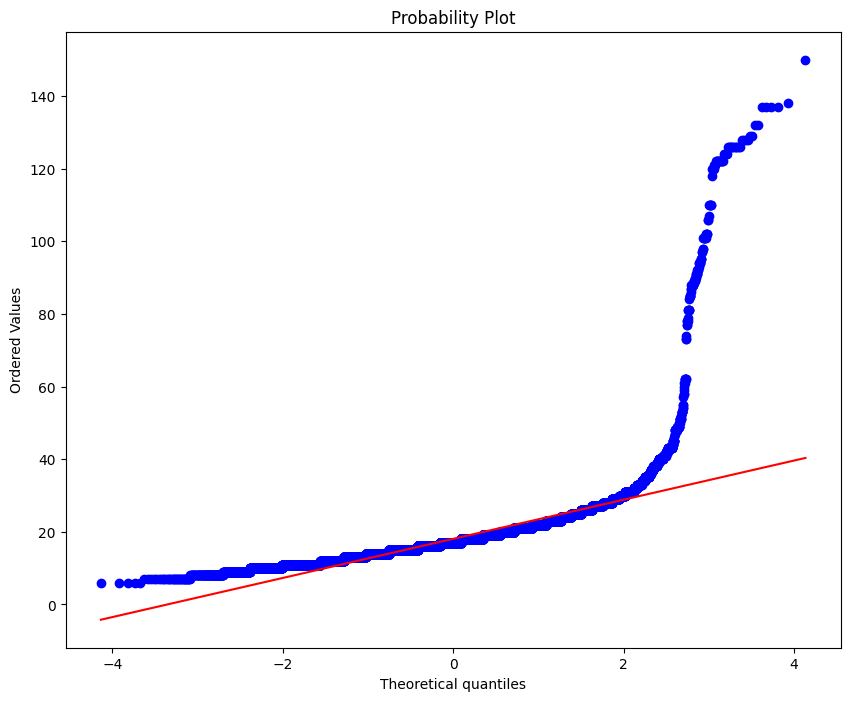

In [60]:
fig, ax = plt.subplots(figsize=(10, 8))
stats.probplot(fueleco.city08, plot=ax)
fig.savefig("/tmp/c5-conprob.png", dpi=300)

## Comparing Continuous Values across Categories

### How to do it...

In [61]:
mask = fueleco.make.isin(["Ford", "Honda", "Tesla", "BMW"])
fueleco[mask].groupby("make").city08.agg(["mean", "std"])

,mean,std
make,,
BMW,17.817377,7.372907
Ford,16.853803,6.701029
Honda,24.372973,9.154064
Tesla,92.826087,5.538970


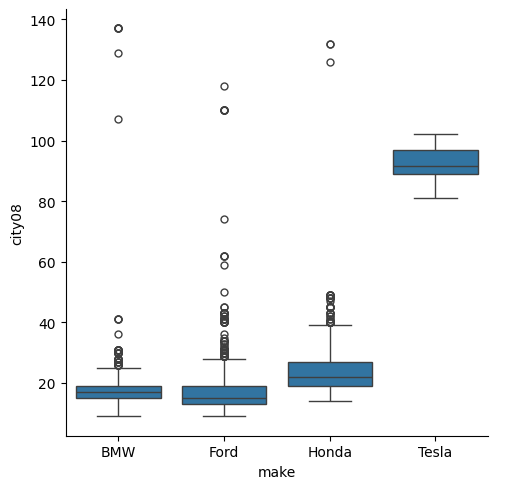

In [62]:
g = sns.catplot(x="make", y="city08", data=fueleco[mask], kind="box")
g.ax.figure.savefig("/tmp/c5-catbox.png", dpi=300)

### How it works...

### There's more...

In [63]:
mask = fueleco.make.isin(["Ford", "Honda", "Tesla", "BMW"])
(
    fueleco[mask].groupby("make").city08.count()
)

make
BMW      1807
Ford     3208
Honda     925
Tesla      46
Name: city08, dtype: int64

In [64]:
# /workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399:
# UserWarning: 59.3% of the points cannot be placed;
# you may want to decrease the size of the markers or use stripplot.
#   warnings.warn(msg, UserWarning)

/workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 54.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 63.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='make', ylabel='city08'>

/workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 58.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 67.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/workspace/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


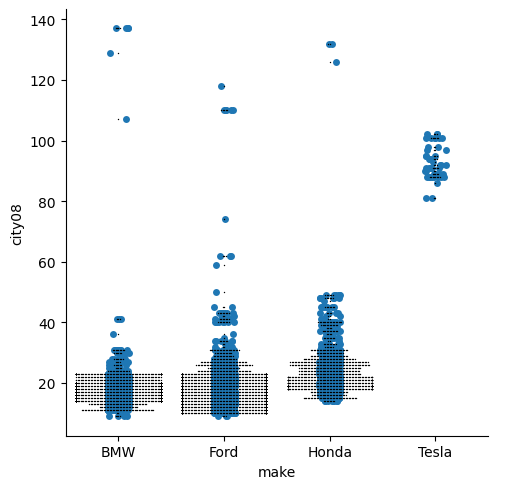

In [65]:
g = sns.catplot(x="make", y="city08", data=fueleco[mask], kind='strip')
sns.swarmplot(
    x="make",
    y="city08",  # doctest: +SKIP
    data=fueleco[mask],
    color="k",
    size=1
)

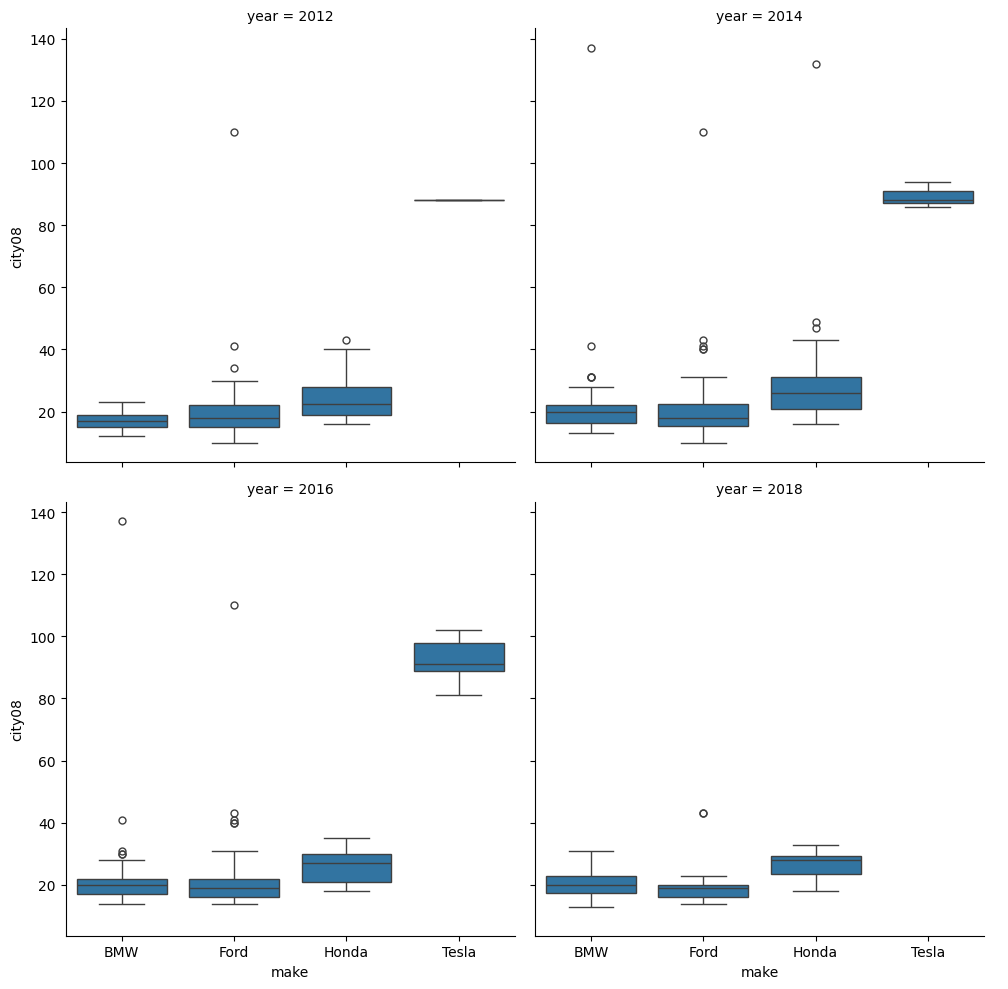

In [66]:
g = sns.catplot(
    x="make",
    y="city08",
    data=fueleco[mask],
    kind="box",
    col="year",
    col_order=[2012, 2014, 2016, 2018],
    col_wrap=2,
)
g.axes[0].figure.savefig("/tmp/c5-catboxcol.png", dpi=300)  # doctest: +SKIP

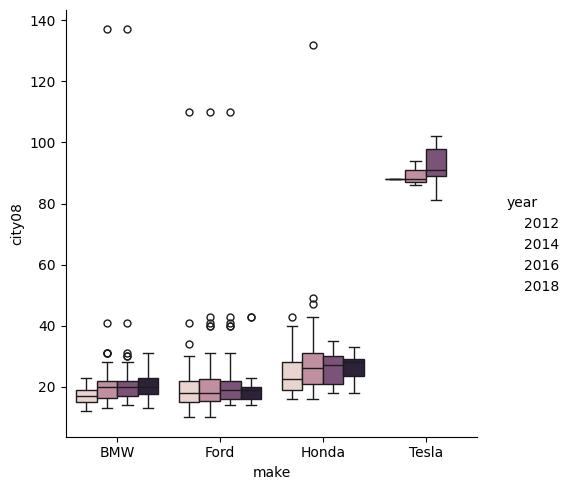

In [67]:
mask = fueleco.make.isin(["Ford", "Honda", "Tesla", "BMW"]) & fueleco.year.isin([2012, 2014, 2016, 2018])

g = sns.catplot(
    x="make",
    y="city08",  # doctest: +SKIP
    data=fueleco[mask],
    kind="box",
    hue="year",
    hue_order=[2012, 2014, 2016, 2018],
)
g.ax.figure.savefig("/tmp/c5-catboxhue.png", dpi=300)  # doctest: +SKIP

In [68]:
mask = fueleco.make.isin(["Ford", "Honda", "Tesla", "BMW"])
(
    fueleco[mask]
    .groupby("make")
    .city08.agg(["mean", "std"])
    .style.background_gradient(cmap="RdBu", axis=0)
)

,mean,std
make,,
BMW,17.817377,7.372907
Ford,16.853803,6.701029
Honda,24.372973,9.154064
Tesla,92.826087,5.538970


## Comparing Two Continuous Columns

### How to do it...

In [ ]:
# Covariance varies with the scale
print(f"{fueleco.city08.cov(fueleco.highway08)=}")
print(f"{fueleco.city08.cov(fueleco.highway08) * 2=}")


fueleco.city08.cov(fueleco.highway08)=46.33326023673624
fueleco.city08.cov(fueleco.highway08) * 2=92.66652047347247


In [70]:
fueleco.city08.cov(fueleco.comb08)

47.419946678190776

In [71]:
fueleco.city08.cov(fueleco.cylinders)

-5.931560263764768

In [72]:
# Correlation is scale invariant
print(f"{fueleco.city08.corr(fueleco.highway08)=}")
print(f"{fueleco.city08.corr(fueleco.highway08 * 2)=}")

fueleco.city08.corr(fueleco.highway08)=0.932494506228495
fueleco.city08.corr(fueleco.highway08 * 2)=0.932494506228495


In [73]:
fueleco.city08.corr(fueleco.cylinders)

-0.7016548423827895

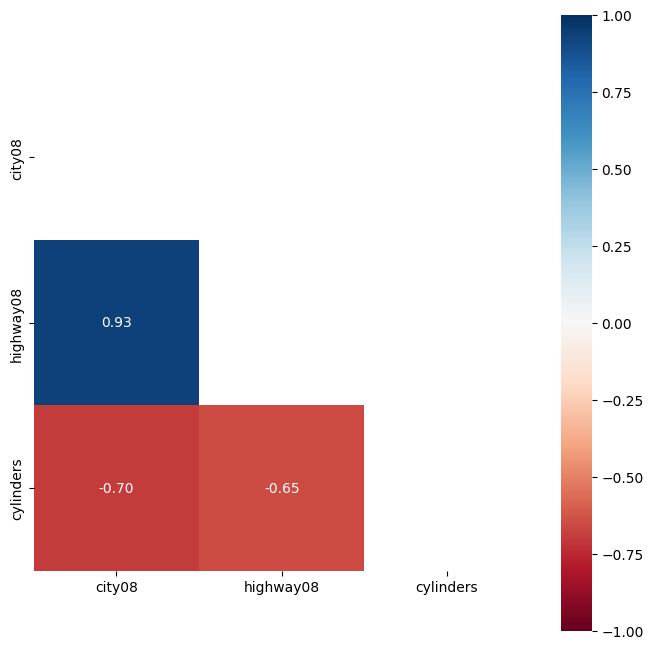

In [75]:
fig, ax = plt.subplots(figsize=(8, 8))
corr = fueleco[["city08", "highway08", "cylinders"]].corr()
mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr,
    mask=mask,
    fmt=".2f",
    annot=True,
    ax=ax,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    square=True,
)
fig.savefig("/tmp/c5-heatmap.png", dpi=300, bbox_inches="tight")

In [77]:
corr = fueleco[["city08", "highway08", "cylinders"]].corr()
corr

,city08,highway08,cylinders
city08,1.000000,0.932495,-0.701655
highway08,0.932495,1.000000,-0.650621
cylinders,-0.701655,-0.650621,1.000000


In [78]:
mask = np.zeros_like(corr, dtype=np.bool_)
mask

array([[False, False, False],
       [False, False, False],
       [False, False, False]])

In [79]:
np.triu_indices_from(mask) # Return the indices for the upper-triangle of arr.

(array([0, 0, 0, 1, 1, 2]), array([0, 1, 2, 1, 2, 2]))

In [80]:
mask[np.triu_indices_from(mask)] = True
mask

array([[ True,  True,  True],
       [False,  True,  True],
       [False, False,  True]])

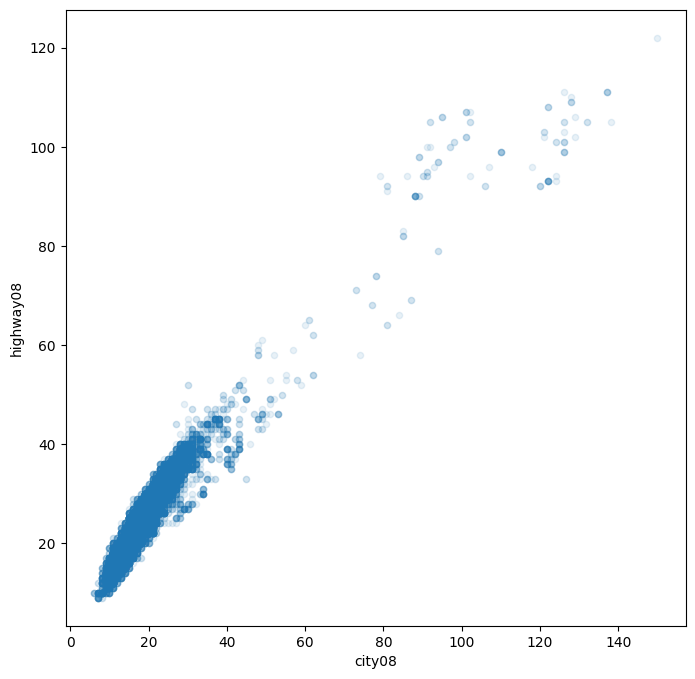

In [81]:
fig, ax = plt.subplots(figsize=(8, 8))
fueleco.plot.scatter(x="city08", y="highway08", alpha=0.1, ax=ax)
fig.savefig("/tmp/c5-scatpan.png", dpi=300, bbox_inches="tight")

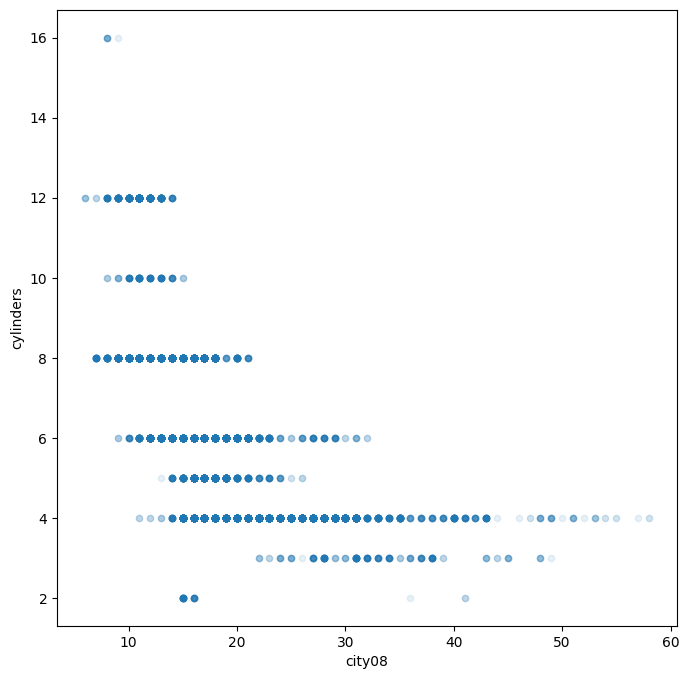

In [82]:
fig, ax = plt.subplots(figsize=(8, 8))
fueleco.plot.scatter(x="city08", y="cylinders", alpha=0.1, ax=ax)
fig.savefig("/tmp/c5-scatpan-cyl.png", dpi=300, bbox_inches="tight")

In [83]:
fueleco.cylinders.isna().sum()

145

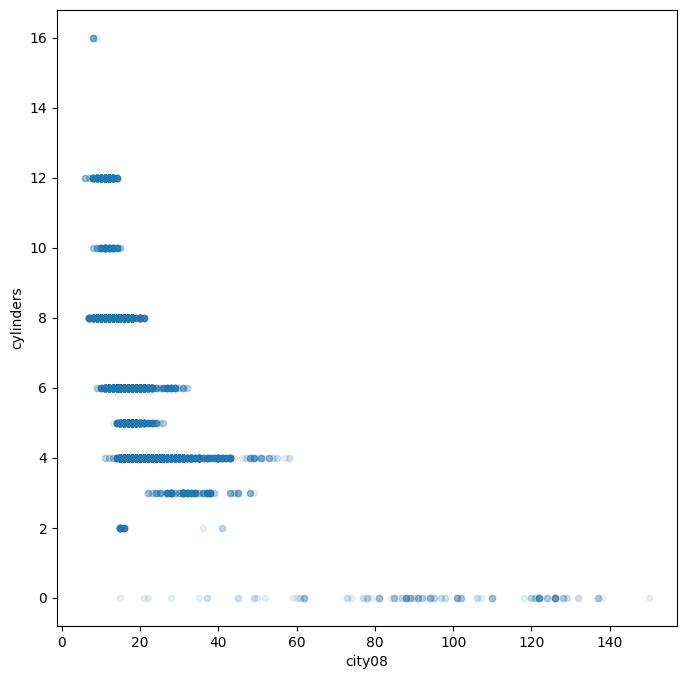

In [84]:
fig, ax = plt.subplots(figsize=(8, 8))
(
    fueleco.assign(cylinders=fueleco.cylinders.fillna(0)).plot.scatter(
        x="city08", y="cylinders", alpha=0.1, ax=ax
    )
)
fig.savefig("/tmp/c5-scatpan-cyl0.png", dpi=300, bbox_inches="tight")

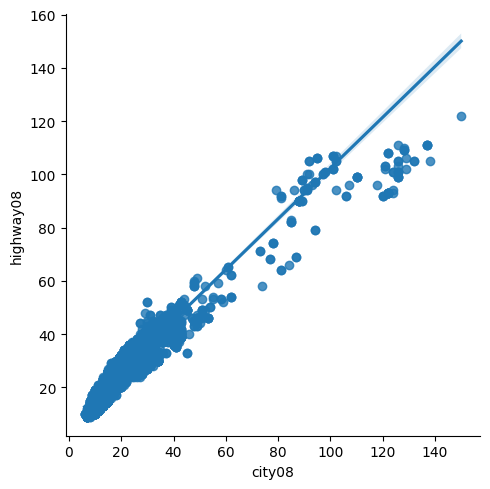

In [85]:
res = sns.lmplot(x="city08", y="highway08", data=fueleco)
res.figure.savefig("/tmp/c5-lmplot.png", dpi=300, bbox_inches="tight")

### How it works...

In [86]:
fueleco.city08.corr(fueleco.highway08 * 2)

0.932494506228495

In [87]:
fueleco.city08.cov(fueleco.highway08 * 2)

92.66652047347247

### There's more...

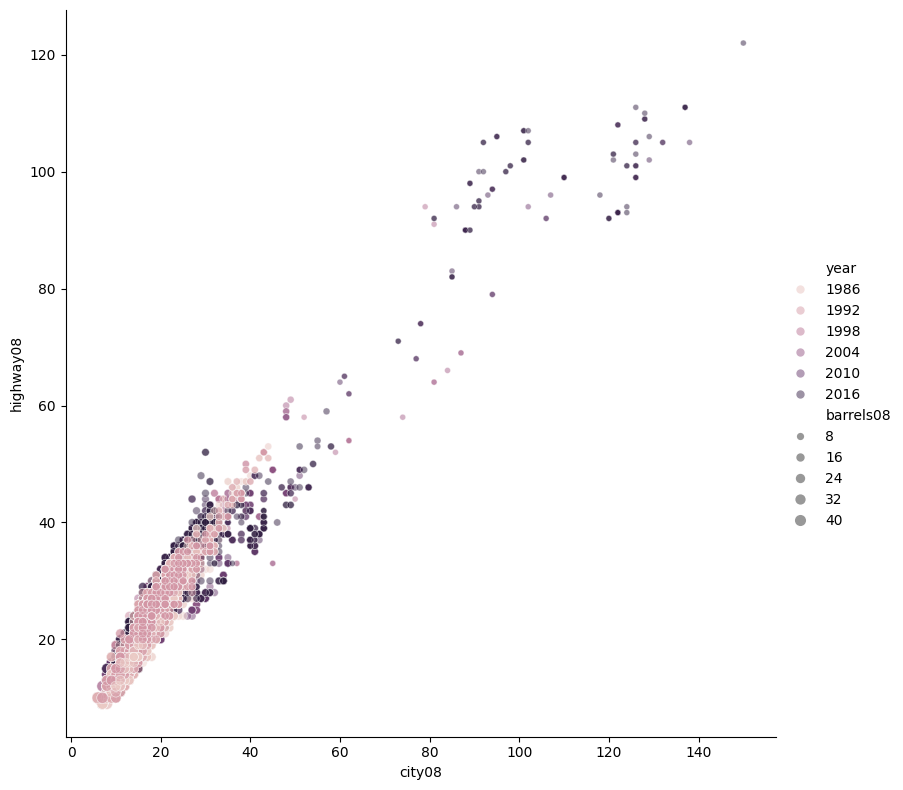

In [88]:
res = sns.relplot(
    x="city08",
    y="highway08",
    data=fueleco.assign(cylinders=fueleco.cylinders.fillna(0)),
    hue="year",
    size="barrels08",
    alpha=0.5,
    height=8,
)
res.figure.savefig("/tmp/c5-relplot2.png", dpi=300, bbox_inches="tight")

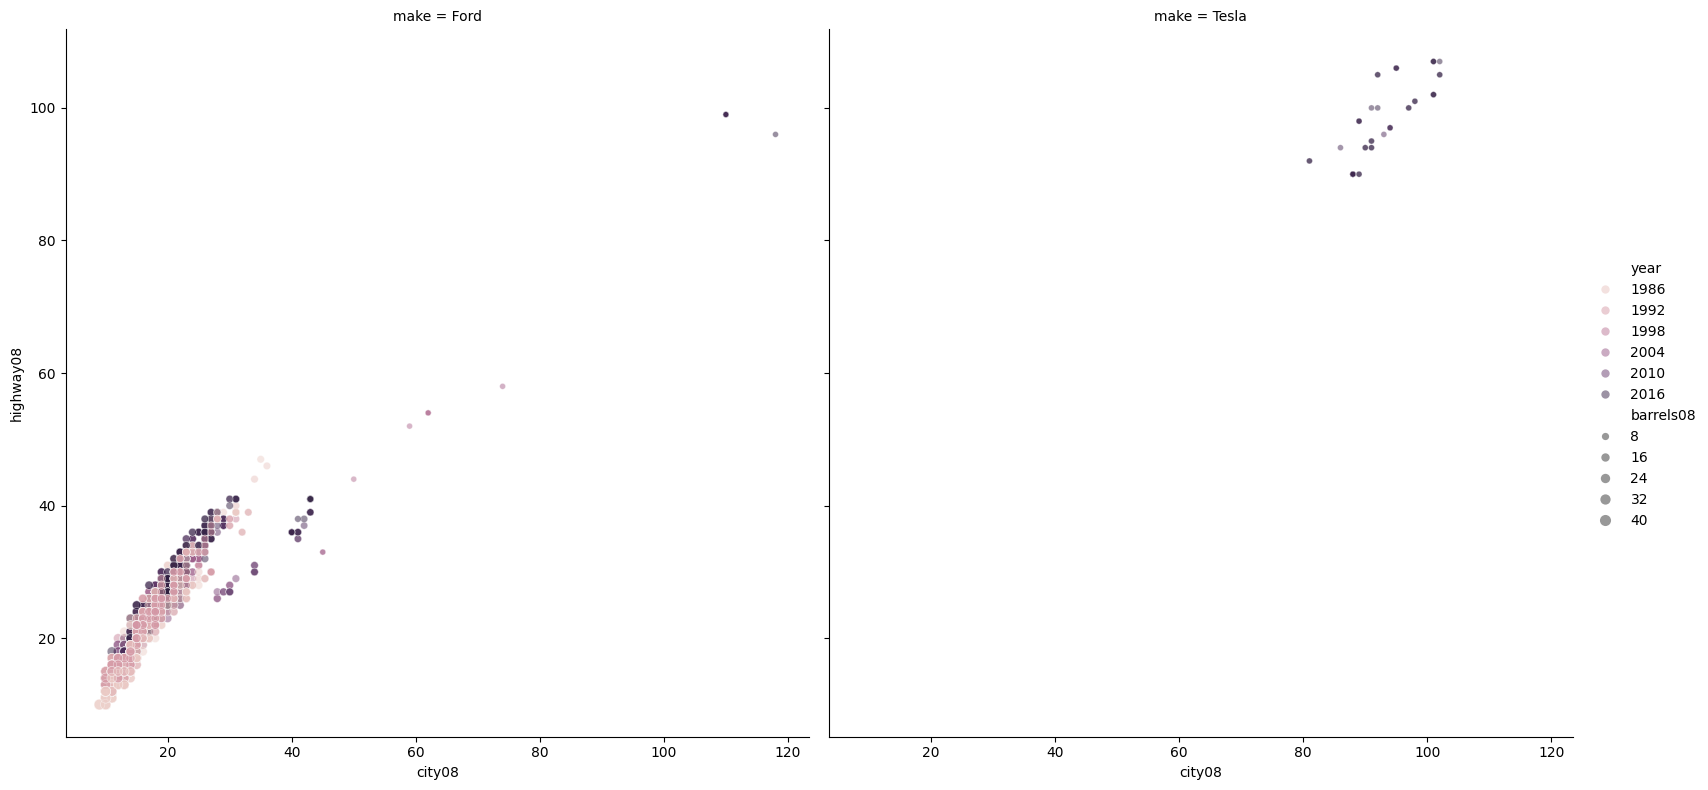

In [89]:
res = sns.relplot(
    x="city08",
    y="highway08",
    data=fueleco.assign(cylinders=fueleco.cylinders.fillna(0)),
    hue="year",
    size="barrels08",
    alpha=0.5,
    height=8,
    col="make",
    col_order=["Ford", "Tesla"],
)
res.figure.savefig("/tmp/c5-relplot3.png", dpi=300, bbox_inches="tight")

In [90]:
fueleco.city08.corr(fueleco.barrels08, method="spearman")

-0.9743658763718624

## Comparing Categorical and Categorical Values

### How to do it...

In [91]:
fueleco.VClass.value_counts().index

Index(['Compact Cars', 'Subcompact Cars', 'Midsize Cars',
       'Standard Pickup Trucks', 'Sport Utility Vehicle - 4WD', 'Large Cars',
       'Two Seaters', 'Sport Utility Vehicle - 2WD', 'Small Station Wagons',
       'Special Purpose Vehicles', 'Minicompact Cars',
       'Standard Pickup Trucks 2WD', 'Vans', 'Standard Pickup Trucks 4WD',
       'Midsize-Large Station Wagons', 'Special Purpose Vehicle 2WD',
       'Small Sport Utility Vehicle 4WD', 'Small Pickup Trucks',
       'Midsize Station Wagons', 'Standard Sport Utility Vehicle 4WD',
       'Small Sport Utility Vehicle 2WD', 'Small Pickup Trucks 2WD',
       'Vans, Cargo Type', 'Minivan - 2WD', 'Vans, Passenger Type',
       'Special Purpose Vehicle 4WD', 'Small Pickup Trucks 4WD',
       'Standard Sport Utility Vehicle 2WD', 'Minivan - 4WD',
       'Standard Pickup Trucks/2wd', 'Vans Passenger',
       'Special Purpose Vehicles/2wd', 'Special Purpose Vehicles/4wd',
       'Special Purpose Vehicle'],
      dtype='object', name

In [92]:
def generalize(ser, match_name, default):
    seen = None
    for match, name in match_name:
        mask = ser.str.contains(match)
        if seen is None:
            seen = mask
        else:
            seen |= mask
        ser = ser.where(~mask, name)
    ser = ser.where(seen, default)
    return ser

In [93]:
makes = ["Ford", "Tesla", "BMW", "Toyota"]
data = fueleco[fueleco.make.isin(makes)].assign(
    SClass=lambda df_: generalize(
        df_.VClass,
        [
            ("Seaters", "Car"),
            ("Car", "Car"),
            ("Utility", "SUV"),
            ("Truck", "Truck"),
            ("Van", "Van"),
            ("van", "Van"),
            ("Wagon", "Wagon"),
        ],
        "other",
    )
)

In [94]:
data.groupby(["make", "SClass"]).size().unstack()

SClass,Car,SUV,Truck,Van,Wagon,other
make,,,,,,
BMW,1557.0,158.0,NaN,NaN,92.0,NaN
Ford,1075.0,372.0,1040.0,332.0,155.0,234.0
Tesla,36.0,10.0,NaN,NaN,NaN,NaN
Toyota,773.0,376.0,478.0,94.0,132.0,123.0


In [95]:
pd.crosstab(data.make, data.SClass)

SClass,Car,SUV,Truck,Van,Wagon,other
make,,,,,,
BMW,1557,158,0,0,92,0
Ford,1075,372,1040,332,155,234
Tesla,36,10,0,0,0,0
Toyota,773,376,478,94,132,123


In [96]:
pd.crosstab([data.year, data.make], [data.SClass, data.VClass])

SClass               Car                                           ...  \
VClass      Compact Cars Large Cars Midsize Cars Minicompact Cars  ...   
year make                                                          ...   
1984 BMW               6          0            0            0      ...   
     Ford             33          3            9            0      ...   
     Toyota           13          0            0            3      ...   
1985 BMW               7          0            0            0      ...   
     Ford             31          2            5            0      ...   
...                  ...        ...          ...          ...      ...   
2017 Tesla             0          8            0            0      ...   
     Toyota            3          0           16            2      ...   
2018 BMW              37         12            5            0      ...   
     Ford              0          0            8            0      ...   
     Toyota            4          0           16            0      ...   

SClass                     Wagon                       other  \
VClass      Small Station Wagons Special Purpose Vehicle 2WD   
year make                                                      
1984 BMW               0                    0                  
     Ford             12                    0                  
     Toyota           10                    0                  
1985 BMW               0                    0                  
     Ford             13                    5                  
...                  ...                  ...                  
2017 Tesla             0                    0                  
     Toyota            0                    0                  
2018 BMW               2                    0                  
     Ford              0                    6                  
     Toyota            0                    0                  

SClass                                                            
VClass      Special Purpose Vehicle 4WD Special Purpose Vehicles  
year make                                                         
1984 BMW               0                           0              
     Ford             21                           6              
     Toyota            3                           2              
1985 BMW               0                           0              
     Ford              9                           6              
...                  ...                         ...              
2017 Tesla             0                           0              
     Toyota            0                           0              
2018 BMW               0                           0              
     Ford              0                           0              
     Toyota            0                           0              

[111 rows x 29 columns]

In [ ]:
# use Cramers to determine categorical correlation
# 		- https://stackoverflow.com/questions/46498455/categorical-features-correlation
# 		- ranges from 0 to 1 : closer to zero means more indenpendant, closer to 1 means more correlated
# 		- custom function
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

In [98]:
cramers_v(data.make, data.SClass)

0.2859720982171866

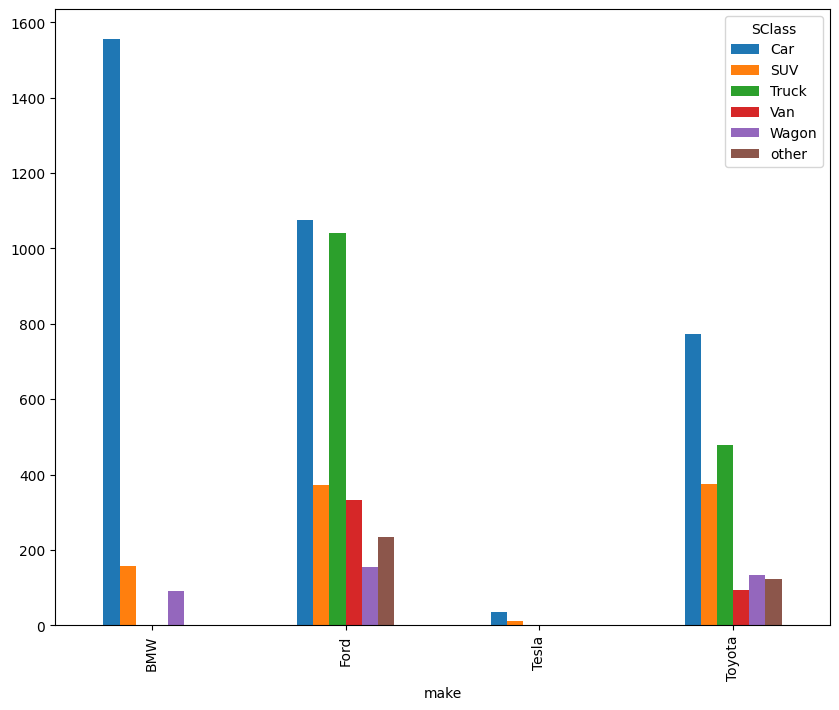

In [99]:
fig, ax = plt.subplots(figsize=(10, 8))
(
    data.pipe(lambda df_: pd.crosstab(df_.make, df_.SClass))
        .plot.bar(ax=ax))
fig.savefig("/tmp/c5-bar.png", dpi=300, bbox_inches="tight")

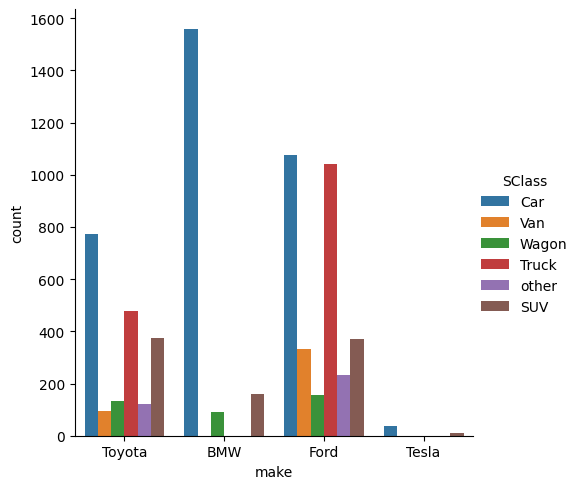

In [100]:
res = sns.catplot(kind="count", x="make", hue="SClass", data=data)
res.figure.savefig("/tmp/c5-barsns.png", dpi=300, bbox_inches="tight")

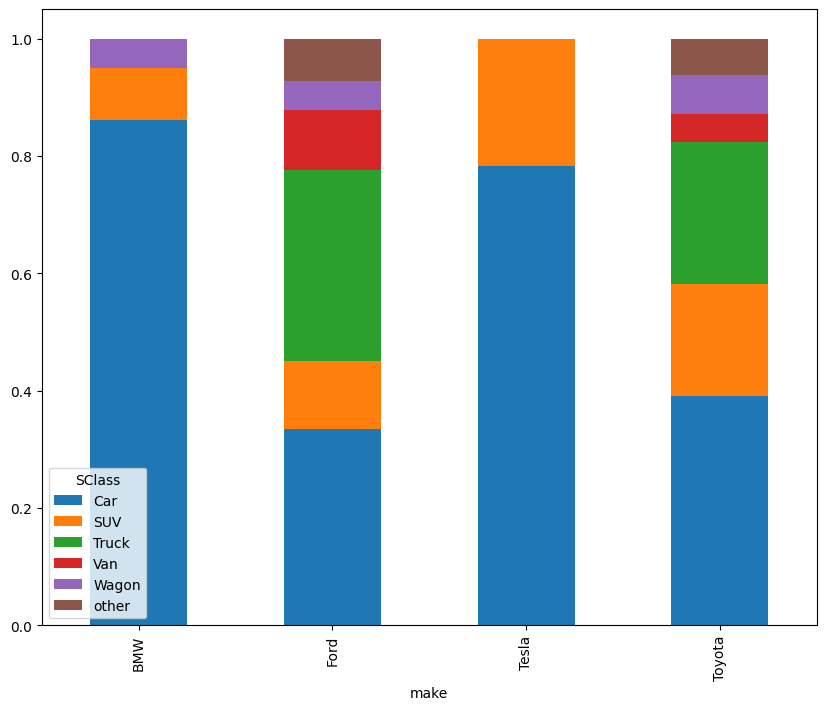

In [101]:
fig, ax = plt.subplots(figsize=(10, 8))
(
    data.pipe(lambda df_: pd.crosstab(df_.make, df_.SClass))
    .pipe(lambda df_: df_.div(df_.sum(axis=1), axis=0))
    .plot.bar(stacked=True, ax=ax)
)
fig.savefig("/tmp/c5-barstacked.png", dpi=300, bbox_inches="tight")

### How it works...

In [102]:
with pd.option_context("display.max_colwidth", 30) :
    display(data[["make", "trany"]])
    display(data[["make", "trany"]].describe().loc[["count", "unique"], :])

,make,trany
7,Toyota,Automatic 3-spd
8,Toyota,Manual 5-spd
9,Toyota,Automatic 4-spd
10,Toyota,Manual 5-spd
20,BMW,Automatic 5-spd
...,...,...
39014,Ford,Manual 5-spd
39015,Ford,Automatic 3-spd
39016,Ford,Manual 5-spd
39017,Ford,Automatic 3-spd


,make,trany
count,7037,7029
unique,4,23


In [ ]:
cramers_v(data.make, data.trany)

0.6335899102918267

In [104]:
cramers_v(data.make, data.model) # closer to 1 : intuitively makes sense as we could derive model from the brand (make)

0.9542350243671587

## Using the Pandas Profiling Library

### How to do it...

https://pypi.org/project/pandas-profiling/

⚠️ pandas-profiling package naming was changed. To continue profiling data use ydata-profiling instead!

pip install ydata-profiling

In [107]:
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(fueleco, title="Profiling Report")
    profile.to_file("fueleco_report.html")
except ModuleNotFoundError as e:
    print("ModuleNotFoundError: ", e)
    print("Downgrading packages for ydata_profiles resulted in this error:")
    print(". seaborn import : AttributeError: module 'matplotlib.cm' has no attribute 'register_cmap'")
    print("Known issue with python 3.12 - use another automatic EDA lib such as DataPrep, sweetviz, AutoViz")


ModuleNotFoundError:  No module named 'ydata_profiling'
Downgrading packages for ydata_profiles resulted in this error:
. seaborn import : AttributeError: module 'matplotlib.cm' has no attribute 'register_cmap'
Known issue with python 3.12 - use another automatic EDA lib such as DataPrep, sweetviz, AutoViz
